# Grass Growth rate Analysis
***
This notebook processes the results of the in-game experiment to determine the rate constant in the logistic growth model of grass. See the markdown file for details about the experiment itself.

## Imports
***

In [17]:
import numpy as np
from matplotlib import pyplot as plt
import scipy as sp

## Load Data
***
The file `grass_growth.csv` contains two columns. The first is time since the experiment began, and the second is the number of grass blocks in the 30x30 test area. We'll load the file and separate it into two 1D numpy arrays, then divide the second column by 900 to get the grass cover fraction.

In [18]:
with open("grass_growth.csv", "r") as f:
    whole_file = np.loadtxt(f, delimiter=",")

time = whole_file[:, 0]
grass_frac = whole_file[:, 1]/900

## Plot Grass Population vs Time
***
Let's take a moment to go into some more detail about the logistic function. We know its derivative is

$f'(x) = kf(x)(1-f(x))$

But what is the actual expression for f(x)? That expression for f'(x) is a nonlinear ordinary differential equation (nonlinear being synonymous with pain-in-the-neck). Luckily, someone else has already solved it:

$f(x) = \frac{1}{1+e^{-k(x-x_{0})}}$

Where x<sub>0</sub> is a new constant that just shifts the curve left and right.

Here's what f(x) looks like:

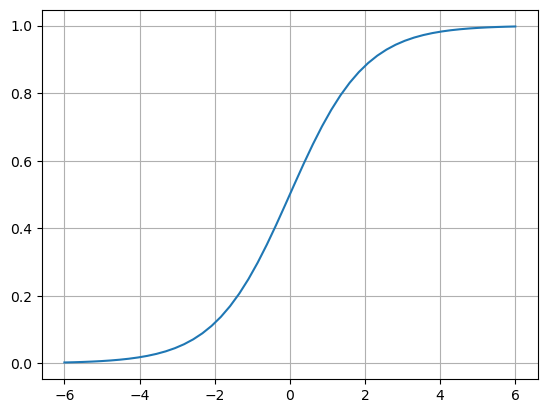

In [19]:
def logistic(x, k, x0):
    return 1/(1 + np.exp(-k * (x - x0)))

f, ax = plt.subplots()

x_example = np.linspace(-6, 6)
y_example = logistic(x_example, 1, 0)

ax.plot(x_example, y_example)
ax.grid(True)

plt.show()

***
If we plot the grass population vs time, we should see something similar:

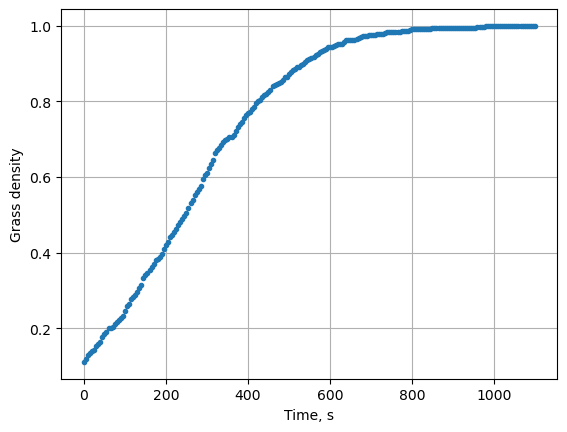

In [20]:
f, ax = plt.subplots()

ax.plot(time, grass_frac, ".")
ax.grid(True)
ax.set_xlabel("Time, s")
ax.set_ylabel("Grass density")

plt.show()

## Fitting logistic function to grass density
***
We should be able to get a good estimate for k by fitting this expression for f(x) to the grass data. We'll use `scipy.optimize.curve_fit` for this.

We'll need some initial guesses for k and x0. We can estimate x0 from the graph above - f(x) crosses 0.5 at x = x0. We can also estimate k from the graph - the slope of f(x) is 0.25k at f(x) = 0.5.

From there, we can call `curve_fit` with the logistic function we defined earlier and the grass data, and get our value for k:

In [21]:
#estimate x0 and k from the graph above
guess = [0.008, 250]

solution = sp.optimize.curve_fit(logistic, time, grass_frac, p0 = guess)

print("x0 = {0}\nk = {1}".format(solution[0][1], solution[0][0]))

x0 = 243.28953052416608
k = 0.007728472838837992


***
Now let's see how the fit lines up:

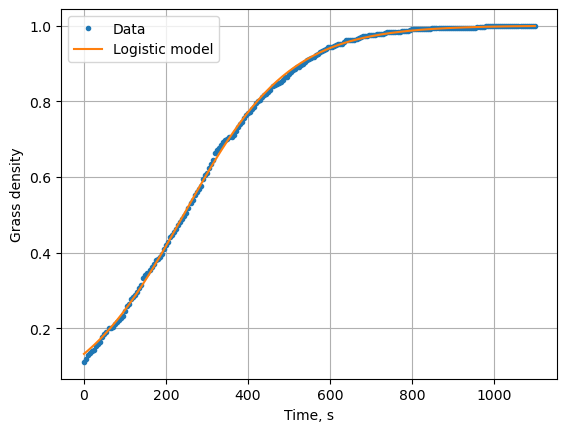

In [22]:
grass_fit = logistic(time, solution[0][0], solution[0][1])

f, ax = plt.subplots()

ax.plot(time, grass_frac, ".", label="Data")
ax.plot(time, grass_fit, "-", label="Logistic model")

ax.grid(True)
ax.set_xlabel("Time, s")
ax.set_ylabel("Grass density")

ax.legend()

plt.show()

***
Pretty good.

## Fitting logistic derivative to growth rate
***
There's another approach we could take. From the grass cover data, we can calculate the grass growth rate. We can then plot the grass cover vs. the grass growth rate, i.e. plotting the grass cover vs. its own derivative. From the equation

$f'(x) = kf(x)(1-f(x))$

We expect to see a parabola. We can fit a parabola, y = k(x - x<sup>2</sup>), and ideally we should get a value for k close to what we got from fitting the grass cover data.

We'll start by calculating those derivatives.

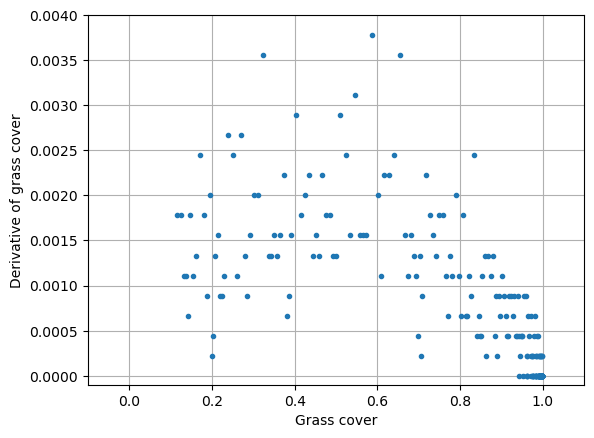

In [23]:
grass_deriv = np.empty(grass_frac.size-1)
grass_cover_midpoint = np.empty(grass_frac.size-1)

#we will calculate the derivatives at the midpoint between adjacent data points
for i in range(0, grass_frac.size-1):
    #change in grass cover over change in time
    grass_deriv[i] = (grass_frac[i+1] - grass_frac[i]) / 5

    #get the grass cover at the midpoint between the two data points
    grass_cover_midpoint[i] = (grass_frac[i+1] + grass_frac[i]) / 2

f, ax = plt.subplots()

ax.plot(grass_cover_midpoint, grass_deriv, ".")
ax.grid(True)
ax.axis([-0.1, 1.1, -0.0001, 0.004])
ax.set_xlabel("Grass cover")
ax.set_ylabel("Derivative of grass cover")

plt.show()

***
Derivatives tend to make noise much more prominent, hence the large amount of scatter in the graph. Still, there is a distinct parabolic shape. We'll go ahead and perform a fit and see what we get for k:

In [24]:
def parabola(x, k):
    return k * (x - x**2)

#We will use the same guess as before for k
solution2 = sp.optimize.curve_fit(parabola, grass_cover_midpoint, grass_deriv, p0 = [0.008])

print("k = {0}".format(solution2[0][0]))

k = 0.007832234909054289


Pretty close to what we had before! Let's see how the graphs line up:

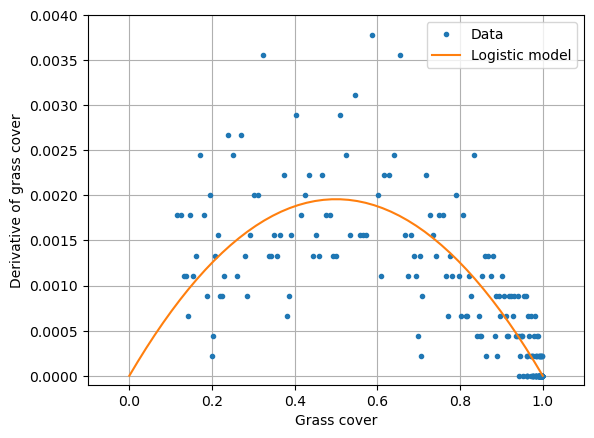

In [25]:
grass_deriv_fit = parabola(np.linspace(0,1), solution2[0][0])

f, ax = plt.subplots()

ax.plot(grass_cover_midpoint, grass_deriv, ".", label="Data")
ax.plot(np.linspace(0,1), grass_deriv_fit, "-", label="Logistic model")

ax.grid(True)
ax.axis([-0.1, 1.1, -0.0001, 0.004])
ax.set_xlabel("Grass cover")
ax.set_ylabel("Derivative of grass cover")

ax.legend()

plt.show()

***
Now that we have values for k, we can proceed with modelling.